In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("/content/bestsellers with categories.csv")

df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [6]:
print(df.shape)

(550, 7)


Датасет містить 550 книг


In [7]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']


In [8]:
df.isna().sum()

,0
name,0
author,0
user_rating,0
reviews,0
price,0
year,0
genre,0


Пропусків нема

In [9]:
df["genre"].unique()

array(['Non Fiction', 'Fiction'], dtype=object)

Унікальні жанри ['Non Fiction', 'Fiction']

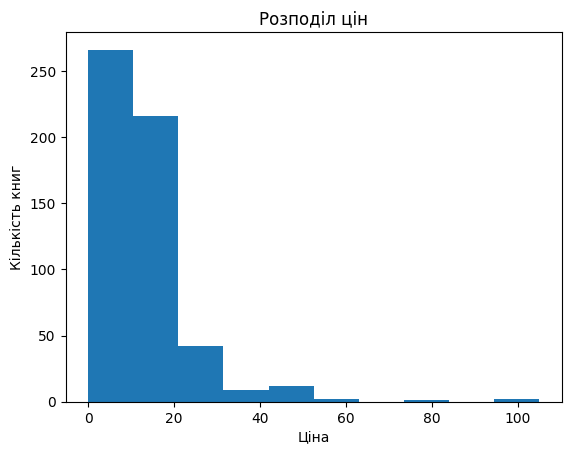

In [17]:
df["price"].plot(kind="hist")
plt.title("Розподіл цін")
plt.xlabel("Ціна")
plt.ylabel("Кількість книг")
plt.show()

In [18]:
print("Максимальна:", df["price"].max())
print("Мінімальна:", df["price"].min())
print("Середня:", df["price"].mean())
print("Медіана:", df["price"].median())

Максимальна: 105
Мінімальна: 0
Середня: 13.1
Медіана: 11.0


In [21]:
print("Максимальний рейтинг:",df["user_rating"].max())

Максимальний рейтинг: 4.9


In [25]:
print("Кількість книг з рейтингом 4.9",(df["user_rating"] == 4.9).sum())

Кількість книг з рейтингом 4.9 52


In [30]:
print("Найбільше відгуків:",df[df["reviews"] == df["reviews"].max()])

Найбільше відгуків:                         name       author  user_rating  reviews  price  year  \
534  Where the Crawdads Sing  Delia Owens          4.8    87841     15  2019   

       genre  
534  Fiction  


Найдорожча книга 2015:

In [32]:
books2015 = df[df["year"] == 2015]

books2015[books2015["price"] == books2015["price"].max()]

,name,author,user_rating,reviews,price,year,genre
277,Publication Manual of the American Psychologic...,American Psychological Association,4.5,8580,46,2015,Non Fiction


Кількість книг жанру Fiction потрапили до Топ-50 у 2010 році:

In [34]:
df[(df["genre"] == "Fiction") &(df["year"] == 2010)].shape[0]

20

Книги з рейтингом 4.9 у 2010 та 2011:

In [36]:
df[(df["user_rating"] == 4.9) & (df["year"].isin([2010, 2011]))].shape[0]

1

In [38]:
cheap = df[(df["year"] == 2015) &(df["price"] < 8)]
cheap = cheap.sort_values(by="price")


Остання книга яка потрапила до рейтингу в 2015 році і коштує дешевше за 8 доларів

In [40]:
cheap.iloc[-1]["name"]

'Old School (Diary of a Wimpy Kid #10)'

Мінімальна та максимальна ціна по жанрах

In [42]:
print(df.groupby("genre")["price"].agg(["min", "max"]))

             min  max
genre                
Fiction        0   82
Non Fiction    0  105


In [48]:
author_books = df.groupby("author")["name"].agg("count")
author_books

,name
author,
Abraham Verghese,2
Adam Gasiewski,1
Adam Mansbach,1
Adir Levy,1
Admiral William H. McRaven,1
...,...
Walter Isaacson,3
William Davis,2
William P. Young,2


Розмірність таблиці

In [50]:
author_books.shape

(248,)

Автор з найбільшою кількістю книг

In [52]:
author_books.idxmax()

'Jeff Kinney'

Кількість книг Jeff Kinney

In [53]:
author_books.max()

12

In [54]:
author_rating = df.groupby("author")["user_rating"].agg("mean")
author_rating

,user_rating
author,
Abraham Verghese,4.600000
Adam Gasiewski,4.400000
Adam Mansbach,4.800000
Adir Levy,4.800000
Admiral William H. McRaven,4.700000
...,...
Walter Isaacson,4.566667
William Davis,4.400000
William P. Young,4.600000


Автор з мінімальним середнім рейтингом

In [56]:
author_rating.idxmin()

'Donna Tartt'

Рейтинг Donna Tartt

In [57]:
author_rating.min()

3.9

In [58]:
authors = pd.concat([author_books, author_rating],axis=1)
authors.columns = ["books", "rating"]
authors.head()

,books,rating
author,,
Abraham Verghese,2,4.6
Adam Gasiewski,1,4.4
Adam Mansbach,1,4.8
Adir Levy,1,4.8
Admiral William H. McRaven,1,4.7


In [61]:
authors = authors.sort_values(by=["books", "rating"],ascending=True)
authors.index[0]

'Muriel Barbery'

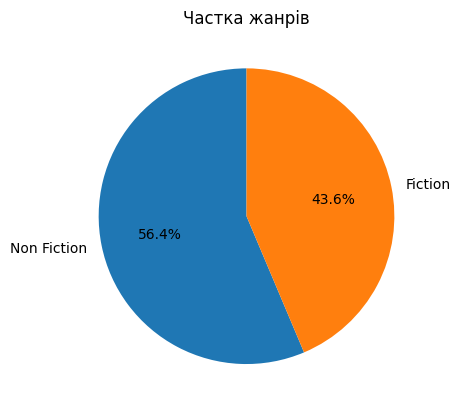

In [63]:
df["genre"].value_counts().plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.ylabel("")
plt.title("Частка жанрів")

plt.show()

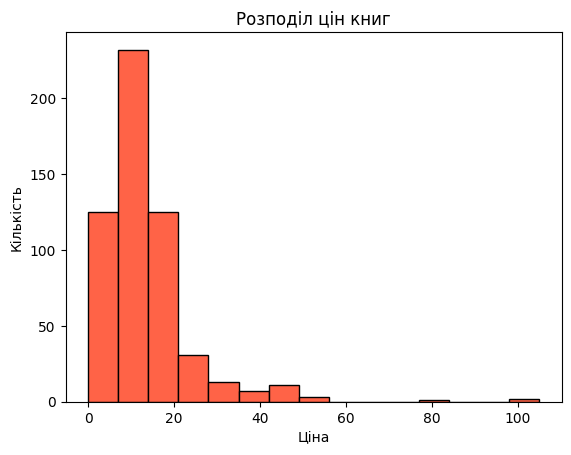

In [65]:
plt.hist(df["price"],bins=15,color="tomato",edgecolor="black")
plt.title("Розподіл цін книг")
plt.xlabel("Ціна")
plt.ylabel("Кількість")
plt.show()

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

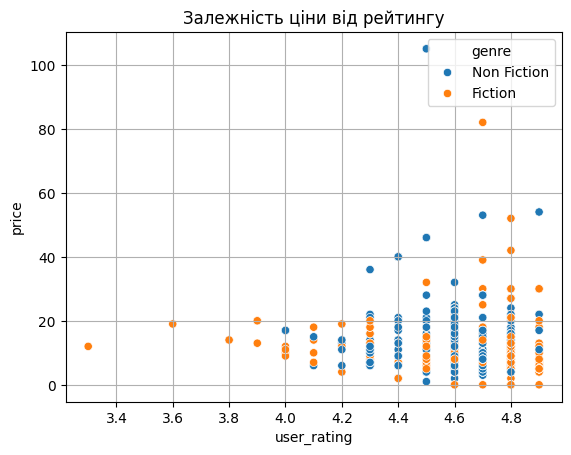

In [70]:
sns.scatterplot(data=df,x="user_rating", y="price",hue="genre",)
plt.title("Залежність ціни від рейтингу")
plt.grid()
plt.show()